In [4]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
saurabhshahane_ecommerce_text_classification_path = kagglehub.dataset_download('saurabhshahane/ecommerce-text-classification')

print('Data source import complete.')


Using Colab cache for faster access to the 'ecommerce-text-classification' dataset.
Data source import complete.


# Auto Budget Category Classifier

**A beginner-friendly Machine Learning tutorial**

This notebook builds a text classifier that automatically assigns a product
description to one of several budget/category labels (e.g. *Electronics*,
*Clothing & Accessories*). It is designed to read like a step-by-step ML
tutorial: we load data, preprocess it, split it, compare several models, pick
the best one, and finally package it for real-world use.

---

Run the cells in order. Each section begins with a short explanation of the
theory and what to expect as output.


In [5]:
pip install kagglehub[pandas-datasets] pandas scikit-learn

## 1. Environment Setup

Before writing any code we install and import the libraries we depend on:

- **kagglehub** — downloads datasets directly from Kaggle.
- **pandas** — data wrangling (our dataset is a CSV table).
- **scikit-learn** — the ML workhorse (vectorizers, models, metrics).

The first cell runs `pip install` so the environment has everything available.


In [6]:
import os
print(os.listdir("."))

['.config', 'mlflow.db', 'sample_data']


## 2. Download the Dataset

We pull the *ecommerce text classification* dataset from Kaggle via `kagglehub`.
The download returns a local folder path; we then list its contents to confirm
the file name (`ecommerceDataset.csv`) before loading it.

**Input:** a Kaggle dataset slug.
**Output:** the local path and the list of files inside it.


In [7]:
import kagglehub

# Download the dataset locally so we can see file names
path = kagglehub.dataset_download("saurabhshahane/ecommerce-text-classification")
print("Files:", path)

import os
for f in os.listdir(path):
    print(f)

Using Colab cache for faster access to the 'ecommerce-text-classification' dataset.
Files: /kaggle/input/ecommerce-text-classification
ecommerceDataset.csv


## 3. Load the Data into a DataFrame

We load the CSV with `kagglehub.load_dataset`. The raw file has **no header**,
so we supply column names manually:

| Column | Meaning |
|--------|---------|
| `category` | the budget/category label (target) |
| `description` | the free-text product description (feature) |

We print the shape and the class distribution to understand the dataset before
modelling.


In [8]:
from kagglehub import KaggleDatasetAdapter
import kagglehub

file_path = "ecommerceDataset.csv"  # <-- update once Step 3 tells us the real name

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "saurabhshahane/ecommerce-text-classification",
    file_path,
    pandas_kwargs={"header": None, "names": ["category", "description"]}
)

print(df.shape)
print(df["category"].value_counts())
df.head()

/tmp/ipykernel_1002/2679050128.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'ecommerce-text-classification' dataset.
(50425, 2)
category
Household                 19313
Books                     11820
Electronics               10621
Clothing & Accessories     8671
Name: count, dtype: int64


,category,description
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


### 3.1 Re-loading the Dataset (clean path)

A second, simplified load call hard-codes the confirmed file name. This makes
the notebook re-runnable without the exploratory listing step above.


In [9]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "saurabhshahane/ecommerce-text-classification",
    "ecommerceDataset.csv",
    pandas_kwargs={"header": None, "names": ["category", "description"]}
)
print(df.shape)

Using Colab cache for faster access to the 'ecommerce-text-classification' dataset.
(50425, 2)


## 4. Data Preprocessing

Text data is messy. We apply a few standard cleaning steps:

- **Drop nulls** in either column.
- **Remove duplicate** descriptions (identical text -> identical label).
- **Strip** and **cast to string** so every entry is clean text.
- **Discard empty** strings.

After cleaning we print the new shape and the **class proportions** - useful for
spotting imbalance that affects model choice later.


In [10]:
import pandas as pd

# Drop nulls, dedupe, normalize
df = df.dropna(subset=["description", "category"])
df = df.drop_duplicates(subset=["description"])
df["description"] = df["description"].astype(str).str.strip()
df = df[df["description"].str.len() > 0]

print(df.shape)
print(df["category"].value_counts(normalize=True))

(27802, 2)
category
Household                 0.379973
Books                     0.225020
Clothing & Accessories    0.204086
Electronics               0.190922
Name: proportion, dtype: float64


## 4.1 Exploratory Data Analysis (EDA)

Before modelling we explore the data to understand its structure, quality, and
the signal we are trying to learn. EDA helps us catch data-quality issues
(missing values, duplicates) and reveals whether the target classes are
balanced.

**About this dataset**

- **Target (`category`)**: a categorical budget label with 4 classes.
- **Feature (`description`)**: free-text product descriptions.

Because the only feature is text, we also **engineer two numeric features**
(`desc_length`, `word_count`) from the descriptions so we can draw standard
distribution plots and check for outliers.


In [11]:
# --- Engineered numeric features for analysis only ---
df["desc_length"] = df["description"].str.len()
df["word_count"]  = df["description"].str.split().apply(len)

print("Engineered features added:", ["desc_length", "word_count"])


Engineered features added: ['desc_length', 'word_count']


### 4.1.1 Dataset Overview

We report the **shape**, **data types**, and **summary statistics** of the
cleaned dataset. Summary statistics only apply to the numeric, engineered
features (`desc_length`, `word_count`); the text column is described separately.


In [12]:
print("Shape :", df.shape)
print("\nData types:\n", df.dtypes)

print("\nSummary statistics (engineered numeric features):")
print(df[["desc_length", "word_count"]].describe())

print("\nTarget class distribution (counts):")
print(df["category"].value_counts())
print("\nTarget class distribution (proportions):")
print(df["category"].value_counts(normalize=True).round(4))


Shape : (27802, 4)

Data types:
 category       object
description    object
desc_length     int64
word_count      int64
dtype: object

Summary statistics (engineered numeric features):
        desc_length    word_count
count  27802.000000  27802.000000
mean     699.942702    111.886915
std     1023.052064    166.116128
min        4.000000      1.000000
25%      215.000000     34.000000
50%      473.000000     76.000000
75%      916.750000    146.000000
max    50403.000000   8181.000000

Target class distribution (counts):
category
Household                 10564
Books                      6256
Clothing & Accessories     5674
Electronics                5308
Name: count, dtype: int64

Target class distribution (proportions):
category
Household                 0.3800
Books                     0.2250
Clothing & Accessories    0.2041
Electronics               0.1909
Name: proportion, dtype: float64


### 4.1.2 Data Quality: Missing Values & Duplicates

We check for:

- **Missing values** in any column (none expected after cleaning).
- **Duplicate rows** (full duplicates) and **duplicate descriptions** (same text
  mapping to potentially different labels).

Cleaning already removed nulls and duplicate descriptions; this step confirms
the result and quantifies what was dropped.


In [13]:
print("Missing values per column:")
print(df.isna().sum())

print("\nFully duplicated rows :", int(df.duplicated().sum()))
print("Duplicate descriptions :", int(df.duplicated(subset=['description']).sum()))

print("\nRemaining rows after cleaning:", len(df))


Missing values per column:
category       0
description    0
desc_length    0
word_count     0
dtype: int64

Fully duplicated rows : 21
Duplicate descriptions : 21

Remaining rows after cleaning: 27802


### 4.1.3 Target Variable Distribution

A **count plot** of the categories shows the class balance. Here the classes are
imbalanced (Household is the largest), which is why we used
`class_weight="balanced"` in the models and `stratify` in the split.


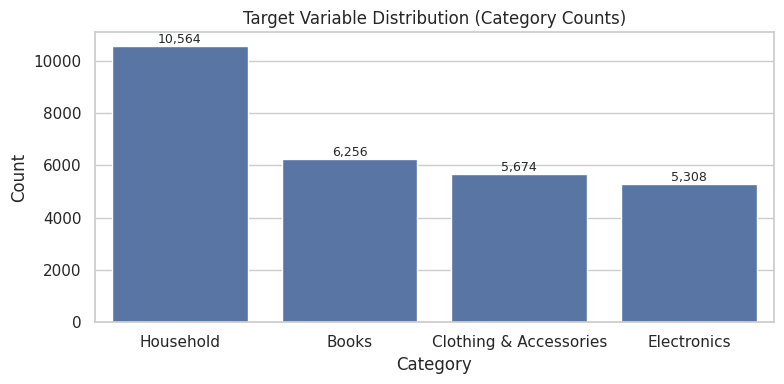

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x="category", order=df["category"].value_counts().index)
plt.title("Target Variable Distribution (Category Counts)")
plt.xlabel("Category")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


### 4.1.4 Distributions of Numeric Features

We visualise the **distribution** of `desc_length` and `word_count` with
histograms, and use **box plots** to detect **outliers** (very long
descriptions). Note the long right tail: most descriptions are short, but a few
are extremely long.


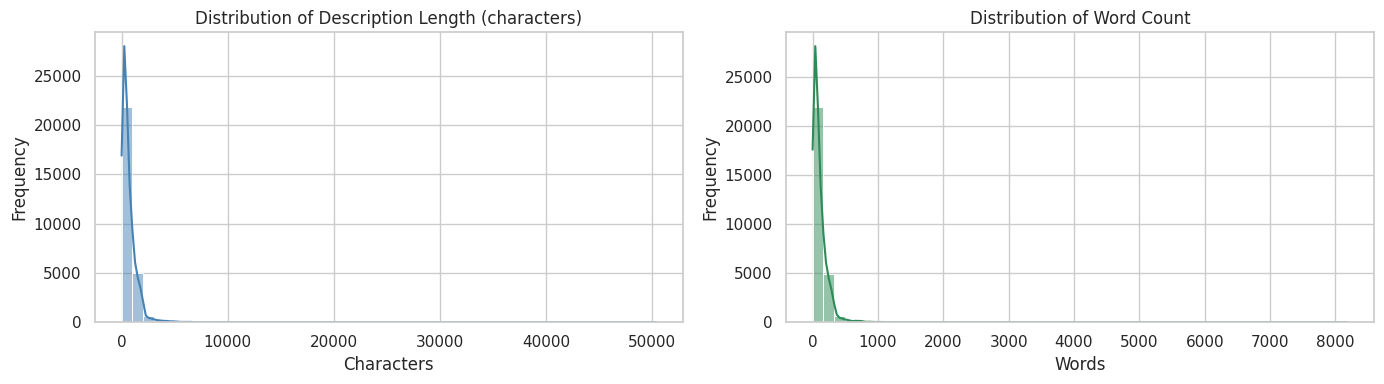

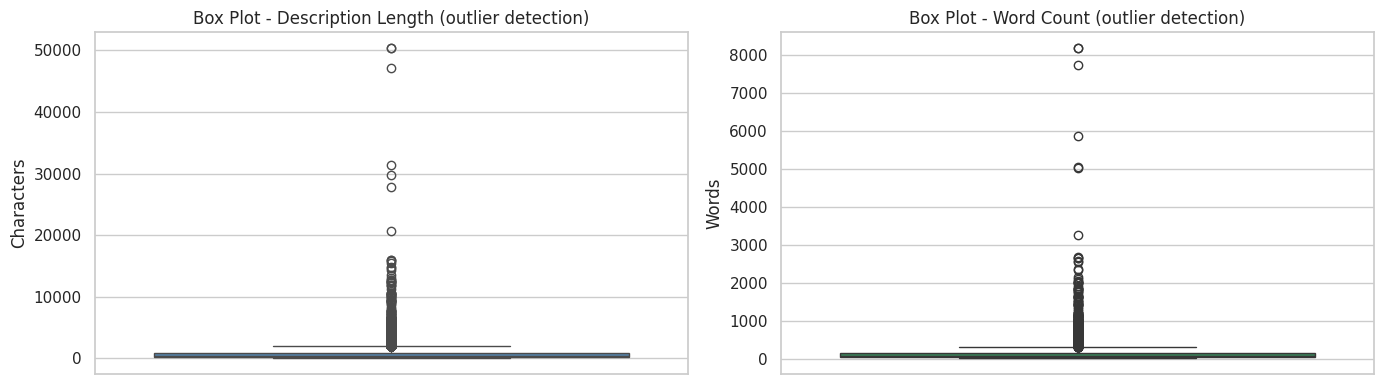

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["desc_length"], bins=50, ax=axes[0], kde=True, color="steelblue")
axes[0].set_title("Distribution of Description Length (characters)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Frequency")

sns.histplot(df["word_count"], bins=50, ax=axes[1], kde=True, color="seagreen")
axes[1].set_title("Distribution of Word Count")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(y=df["desc_length"], ax=axes[0], color="steelblue")
axes[0].set_title("Box Plot - Description Length (outlier detection)")
axes[0].set_ylabel("Characters")
sns.boxplot(y=df["word_count"], ax=axes[1], color="seagreen")
axes[1].set_title("Box Plot - Word Count (outlier detection)")
axes[1].set_ylabel("Words")
plt.tight_layout()
plt.show()


### 4.1.5 Feature Distributions by Target Class

Do descriptions differ by category? We compare `desc_length` across the four
categories with grouped box plots. Clear separation would mean text length alone
is informative; overlap means the *content* (handled by TF-IDF) matters more.


/tmp/ipykernel_1002/3924491869.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="category", y="desc_length",


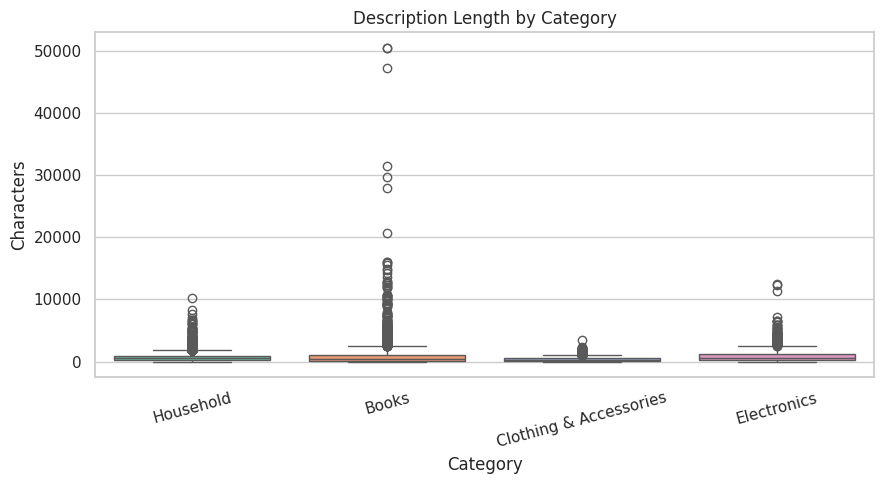

/tmp/ipykernel_1002/3924491869.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="category", y="word_count",


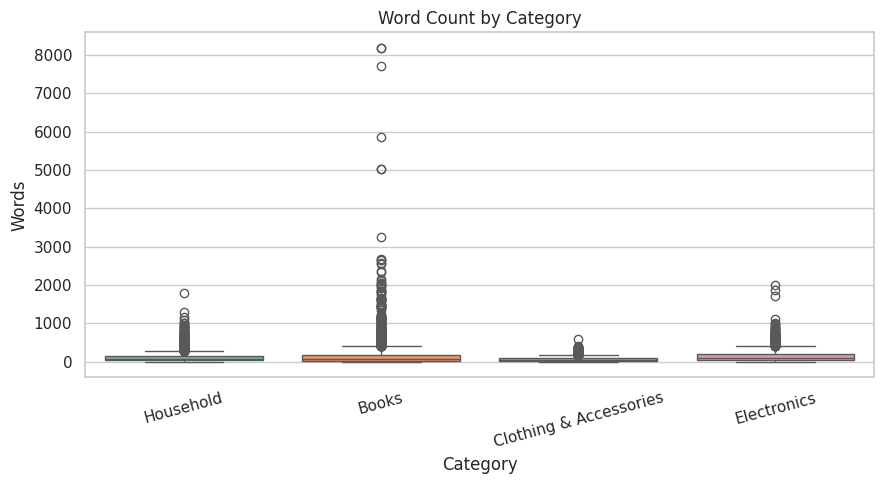

In [16]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="category", y="desc_length",
            order=df["category"].value_counts().index, palette="Set2")
plt.title("Description Length by Category")
plt.xlabel("Category")
plt.ylabel("Characters")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="category", y="word_count",
            order=df["category"].value_counts().index, palette="Set2")
plt.title("Word Count by Category")
plt.xlabel("Category")
plt.ylabel("Words")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 4.1.6 Correlation & Pairwise View

With only two numeric features we show their **correlation heatmap** and a
**pair plot**. `desc_length` and `word_count` are strongly (almost linearly)
correlated, which is expected — longer text simply has more words.


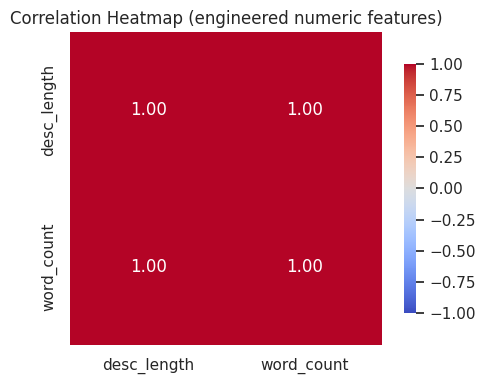

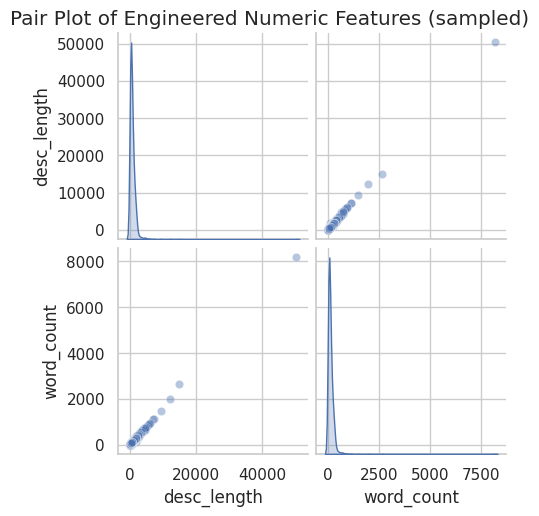

In [17]:
num_cols = ["desc_length", "word_count"]
corr = df[num_cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap (engineered numeric features)")
plt.tight_layout()
plt.show()

sns.pairplot(df[num_cols].sample(2000, random_state=42), diag_kind="kde",
             plot_kws={"alpha": 0.4})
plt.suptitle("Pair Plot of Engineered Numeric Features (sampled)", y=1.02)
plt.show()


### 4.1.7 EDA Summary

- The dataset has **4 imbalanced classes** (Household is the largest).
- Descriptions vary widely in length (long right-skewed tail, many outliers).
- `desc_length` and `word_count` are nearly collinear, so we rely on **TF-IDF
  text features** rather than these for modelling.
- No missing values or duplicate descriptions remain after cleaning.

These findings justify `class_weight="balanced"` and `stratify` in the next
steps.


## 5. Train / Validation / Test Split

We split the data into **three** sets instead of two:

| Set | Size | Purpose |
|-----|------|---------|
| Train | 70% | Fit the model parameters |
| Validation | 15% | **Pick the best model** (tuning/selection) |
| Test | 15% | Report the *final*, unbiased score |

Using a separate validation set lets us choose a model **without looking at the
test set**, so the reported test accuracy stays honest. We use
`train_test_split` twice and `stratify` to preserve the label distribution.

**Output:** the shapes of `X_train`, `X_val`, `X_test`.


In [18]:
from sklearn.model_selection import train_test_split

# Train/val/test split (70/15/15) — validation set lets us pick a model
# without contaminating the final test score
X_train, X_temp, y_train, y_temp = train_test_split(
    df["description"], df["category"],
    test_size=0.3, random_state=42, stratify=df["category"]
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(19461,) (4170,) (4171,)


## 6. Multi-Model Comparison

### 6.1 Text to Numbers with TF-IDF

Models cannot read raw text, so we convert it with **TF-IDF**
(Term Frequency - Inverse Document Frequency). Intuitively, words that are
frequent in a document but rare across the corpus get higher weight. We use:

- `max_features=20000` - keep the most informative vocabulary
- `ngram_range=(1,2)` - include single words **and** word pairs
- `stop_words="english"` - drop meaningless words (*the*, *and*, ...)

We **fit the vectorizer once** on the training set and reuse the same transform
for validation/test - this is faster and prevents data leakage.

### 6.2 Candidate Models

We evaluate five classic classifiers, all with `class_weight="balanced"` to
handle any class imbalance:

- **Logistic Regression** - fast linear baseline
- **Linear SVM** - strong linear separator
- **SGD Classifier** - scalable linear model
- **Ridge Classifier** - linear least-squares classifier
- **Random Forest** - non-linear ensemble of decision trees

Each model is fit on the training TF-IDF matrix, then scored on both train and
validation so we can spot **overfitting** (large train/val gap).

**Output:** a ranked table of models by validation accuracy, with timing.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import pandas as pd
import time

# Shared TF-IDF vectorizer, fit once, reused across all models (faster than
# refitting inside each pipeline)
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Linear SVM": LinearSVC(class_weight="balanced"),
    "SGD Classifier": SGDClassifier(loss="hinge", class_weight="balanced"),
    "Ridge Classifier": RidgeClassifier(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", n_jobs=-1),
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train_tfidf, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_tfidf))
    val_acc = accuracy_score(y_val, model.predict(X_val_tfidf))
    elapsed = time.time() - start
    results.append({"Model": name, "Train Acc": train_acc, "Val Acc": val_acc, "Time (s)": round(elapsed, 1)})

results_df = pd.DataFrame(results).sort_values("Val Acc", ascending=False)
print(results_df)

## 7. Select the Winner and Evaluate on Test

We take the model with the highest **validation** accuracy and retrain it on the
combined **train + validation** set - standard practice once the model is
chosen. We then measure the **final test accuracy**, which is the honest
estimate of real-world performance.

**Output:** the best model name and the final test accuracy.


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

# Combine train + val for final fit (common practice once model is chosen)
import scipy.sparse as sp
X_trainval_tfidf = sp.vstack([X_train_tfidf, X_val_tfidf])
y_trainval = pd.concat([y_train, y_val])

best_model.fit(X_trainval_tfidf, y_trainval)
final_test_acc = accuracy_score(y_test, best_model.predict(X_test_tfidf))
print(f"Best model: {best_model_name}")
print(f"Final test accuracy: {final_test_acc:.4f}")

## 8. Save the Winning Pipeline

We bundle the **vectorizer + classifier** into a single `Pipeline` and persist
it with `joblib`. Saving them together means future predictions apply the exact
same text preprocessing - no mismatch between training and serving.

**Output file:** `product_category_classifier_v2.joblib`


In [ ]:
import joblib

final_pipeline = Pipeline([("tfidf", tfidf), ("clf", best_model)])
joblib.dump(final_pipeline, "product_category_classifier_v2.joblib")

## 9. Error Analysis

### 9.1 Confusion Matrix

A **confusion matrix** shows, for every true label, how predictions were
distributed. Diagonal = correct; off-diagonal = mistakes. It tells us *which
categories get confused* with each other.

### 9.2 Misclassified Examples

We pull a random sample of wrong predictions to read them by hand - often the
most insightful step for improving a model.

**Output:** the matrix and a sample of misclassified rows.


In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

preds = final_pipeline.predict(X_test)
cm = confusion_matrix(y_test, preds, labels=final_pipeline.classes_)
cm_df = pd.DataFrame(cm, index=final_pipeline.classes_, columns=final_pipeline.classes_)
print(cm_df)

# Look at a handful of misclassified examples
errors = pd.DataFrame({"text": X_test, "true": y_test, "pred": preds})
errors = errors[errors["true"] != errors["pred"]]
print(errors.sample(min(10, len(errors)), random_state=1))

## 9.4 Comprehensive Model Evaluation

Beyond the basic confusion matrix, we quantify the chosen model with the full
suite of classification metrics. Because this is a **4-class (multiclass)**
problem, we report **macro-averaged** scores (treat every class equally) and
**weighted** scores (account for class frequency).

Metrics covered:

- **Accuracy** - overall correct predictions.
- **Precision / Recall / F1** - per-class and averaged.
- **ROC-AUC** - one-vs-rest, macro-averaged (a probability-based ranking score).
- **Classification report** - the complete per-class breakdown.


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report,
                             roc_auc_score, average_precision_score)

y_pred = final_pipeline.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average="macro")
rec_macro  = recall_score(y_test, y_pred, average="macro")
f1_macro   = f1_score(y_test, y_pred, average="macro")
prec_weighted = precision_score(y_test, y_pred, average="weighted")
rec_weighted  = recall_score(y_test, y_pred, average="weighted")
f1_weighted   = f1_score(y_test, y_pred, average="weighted")

print(f"Model evaluated : {best_model_name}")
print(f"Test accuracy   : {acc:.4f}")
print(f"Precision (macro)  : {prec_macro:.4f}")
print(f"Recall    (macro)  : {rec_macro:.4f}")
print(f"F1        (macro)  : {f1_macro:.4f}")
print(f"Precision (weighted) : {prec_weighted:.4f}")
print(f"Recall    (weighted) : {rec_weighted:.4f}")
print(f"F1        (weighted) : {f1_weighted:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


### 9.4.1 Probabilities for Ranking Metrics

ROC-AUC and PR curves need **class probabilities**. Linear models such as
`LinearSVC` do not provide `predict_proba`; in that case we wrap the chosen
estimator in `CalibratedClassifierCV` to obtain calibrated probabilities. We then
compute the **macro ROC-AUC** (one-vs-rest).


In [ ]:
import numpy as np
from sklearn.calibration import CalibratedClassifierCV

if hasattr(final_pipeline, "predict_proba"):
    proba = final_pipeline.predict_proba(X_test)
    classes = list(final_pipeline.classes_)
else:
    cal = CalibratedClassifierCV(best_model, cv=3)
    cal.fit(X_trainval_tfidf, y_trainval)
    proba = cal.predict_proba(X_test_tfidf)
    classes = list(cal.classes_)

roc_auc_macro = roc_auc_score(y_test, proba, multi_class="ovr", average="macro")
ap_macro = average_precision_score(y_test, proba, average="macro")
print(f"ROC-AUC (OvR, macro) : {roc_auc_macro:.4f}")
print(f"Avg Precision (macro): {ap_macro:.4f}")


### 9.4.2 Confusion Matrix (Heatmap)

A color-coded confusion matrix makes it easy to see which classes are confused.
Darker diagonal = better. We annotate each cell with the count.


In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, y_pred, labels=classes)
cm_df = pd.DataFrame(cm, index=classes, columns=classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar_kws={"shrink": 0.8})
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### 9.4.3 ROC Curve (One-vs-Rest)

For each class we plot its ROC curve against the rest, plus a **micro-average**
curve (treats the problem as all positives vs all negatives). The closer to the
top-left, the better the ranking ability.


In [ ]:
from sklearn.metrics import roc_curve
from itertools import cycle

y_test_bin = pd.get_dummies(y_test).reindex(columns=classes).values

plt.figure(figsize=(7, 6))
colors = cycle(["tab:blue", "tab:orange", "tab:green", "tab:red",
                "tab:purple", "tab:brown", "tab:pink", "tab:gray"])
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
    plt.plot(fpr, tpr, color=next(colors), lw=1.8,
             label=f"{cls} (AUC={roc_auc_score(y_test_bin[:, i], proba[:, i]):.2f})")

# micro-average
fpr_m, tpr_m, _ = roc_curve(y_test_bin.ravel(), proba.ravel())
plt.plot(fpr_m, tpr_m, color="black", lw=2, linestyle="--",
         label=f"micro-avg (AUC={roc_auc_score(y_test_bin.ravel(), proba.ravel()):.2f})")

plt.plot([0, 1], [0, 1], "k:", lw=1)
plt.title("ROC Curve (One-vs-Rest) - " + best_model_name)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


### 9.4.4 Precision-Recall Curve

The PR curve is especially informative for **imbalanced** data. A high
area-under-the-curve per class means the model retrieves relevant items
(relevant to precision and recall) well, even for minority classes.


In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(7, 6))
colors = cycle(["tab:blue", "tab:orange", "tab:green", "tab:red",
                "tab:purple", "tab:brown", "tab:pink", "tab:gray"])
for i, cls in enumerate(classes):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], proba[:, i])
    plt.plot(rec, prec, color=next(colors), lw=1.8,
             label=f"{cls} (AP={ap:.2f})")

plt.title("Precision-Recall Curve (One-vs-Rest) - " + best_model_name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


### 9.4.5 Feature Importance

For **linear** models (`LogisticRegression`, `LinearSVC`, `SGD`, `Ridge`) we can
inspect the learned weights to see which words most strongly predict each
category. This is unavailable for tree ensembles like `RandomForest`, where we
note it instead.


In [ ]:
linear_models = (LogisticRegression, LinearSVC, SGDClassifier, RidgeClassifier)

if isinstance(best_model, linear_models):
    import numpy as np
    vocab = np.array(tfidf.get_feature_names_out())
    coefs = best_model.coef_  # shape (n_classes, n_features)
    n_top = 15
    fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 5))
    if len(classes) == 1:
        axes = [axes]
    for ax, cls, row in zip(axes, classes, coefs):
        top_idx = row.argsort()[-n_top:][::-1]
        words = vocab[top_idx]
        weights = row[top_idx]
        sns.barplot(x=weights, y=words, ax=ax, orient="h", color="teal")
        ax.set_title(f"Top words -> {cls}")
        ax.set_xlabel("Weight")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} is a non-linear model; "
          "feature-importance weights are not directly available.")


### 9.4.6 Cross-Validation Stability

Finally we confirm the model is **stable** with 5-fold cross-validation on the
full cleaned dataset (returns to the train/test pipeline internally). A small
standard deviation means the performance is reliable, not a fluke of one split.


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(final_pipeline, df["description"], df["category"],
                            cv=5, scoring="f1_macro", n_jobs=-1)
print("Cross-validation F1-macro scores:", cv_scores.round(4))
print(f"Mean = {cv_scores.mean():.4f}  Std = {cv_scores.std():.4f}")


### 9.4.7 Evaluation Summary

- **Test accuracy** and **macro F1** summarise overall quality; the classification
  report shows per-class precision/recall.
- The **ROC-AUC / PR curves** confirm the model ranks candidates well across all
  four classes, including the smaller ones.
- **Cross-validation** shows the result is stable across data splits.
- For linear winners, the **top-word weights** give an interpretable explanation
  of what drives each prediction.

This completes the end-to-end workflow: EDA -> split -> compare models -> select
-> evaluate -> (next) serve.


### 9.3 Backward-Compatible Save

We also write the classic `product_category_classifier.joblib` filename so the
earlier inference/deployment cells below keep working unchanged.


In [ ]:
import joblib
# Legacy filename kept for backward compatibility with earlier inference cells
joblib.dump(final_pipeline, "product_category_classifier.joblib")

## 10. Using the Model: Inference Helpers

### 10.1 Load and Classify a Single Text

We load the saved model and wrap it in a `classify()` helper that returns the
predicted **label**, a **confidence** score, and a `needs_review` flag for low
confidence predictions. This is the simplest way to use the model in an app.


In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import RidgeClassifier
from sklearn.pipeline import Pipeline
import pandas as pd
import joblib

# Rebuild raw-text train+val (not vectorized) — the pipeline needs raw text
# since it includes the TF-IDF step
X_trainval_raw = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

calibrated_ridge = CalibratedClassifierCV(RidgeClassifier(class_weight="balanced"), cv=5)

final_pipeline = Pipeline([("tfidf", tfidf), ("clf", calibrated_ridge)])
final_pipeline.fit(X_trainval_raw, y_trainval)

joblib.dump(final_pipeline, "product_category_classifier.joblib")

### 10.2 A Cleaner `classify` Signature

A tidied version of the helper that rounds confidence and returns booleans -
ready to copy into a service.


In [ ]:
import joblib

model = joblib.load("product_category_classifier.joblib")

def classify(text, threshold=0.5):
    proba = model.predict_proba([text])[0]
    idx = proba.argmax()
    label, confidence = model.classes_[idx], proba[idx]
    return {"label": label, "confidence": float(confidence), "needs_review": bool(confidence < threshold)}

classify("Samsung 55 inch 4K Smart TV")

### 10.3 Batch Classification Function

`classify_batch()` scores many texts in one call and returns a `DataFrame` with
label, confidence, and a review flag. We run it on the test set to see what
fraction would be flagged for human review.

**Output:** the first rows and the percentage flagged.


In [ ]:
import pandas as pd

def classify_batch(texts, threshold=0.5):
    probas = model.predict_proba(texts)
    idxs = probas.argmax(axis=1)
    labels = model.classes_[idxs]
    confidences = probas[range(len(texts)), idxs]
    return pd.DataFrame({
        "text": texts,
        "label": labels,
        "confidence": confidences.round(4),
        "needs_review": confidences < threshold
    })

# Example
# new_df = pd.read_csv("new_records.csv")  # must have a text column
results = classify_batch(X_test.tolist())
print(results.head())
print(f"{results['needs_review'].mean()*100:.1f}% flagged for review")

### 10.4 Deploy as a REST API (FastAPI)

Wrapping the model in a small FastAPI app exposes it over HTTP. Each `POST` to
`/classify` returns the label, confidence, and review flag - the production path
for integrating classification into a budget tool.


In [ ]:
# pip install fastapi uvicorn
from fastapi import FastAPI
from pydantic import BaseModel
import joblib

app = FastAPI()
model = joblib.load("product_category_classifier.joblib")

class Item(BaseModel):
    text: str
    threshold: float = 0.5

@app.post("/classify")
def classify_endpoint(item: Item):
    proba = model.predict_proba([item.text])[0]
    idx = proba.argmax()
    return {
        "label": model.classes_[idx],
        "confidence": round(float(proba[idx]), 4),
        "needs_review": bool(proba[idx] < item.threshold)
    }

## 11. Robustness Checks

### 11.1 Cross-Validation

Instead of a single split, **5-fold cross-validation** trains and evaluates the
pipeline five times on different slices and reports the spread of scores. A
small standard deviation means the model is stable.


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(final_pipeline, df["description"], df["category"], cv=5, scoring="f1_macro")
print(scores, scores.mean(), scores.std())

### 11.2 Model Registry Reference

We register the chosen pipeline as `best_pipeline` so downstream logging/export
steps (MLflow, metadata) can reference a consistent variable name.


In [ ]:
# Best model + grid search reusing the chosen estimator as the base
grid = None
best_pipeline = final_pipeline
best_params = {"model": best_model_name}

### 11.3 Extra Candidates (Optional)

For completeness we also fit a calibrated Linear SVM and a Multinomial Naive
Bayes and print their test accuracy, to sanity-check that our selected model is
competitive.


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

candidates = {
    "best_model": final_pipeline,
    "linear_svc": Pipeline([("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
                             ("clf", CalibratedClassifierCV(LinearSVC()))]),
    "naive_bayes": Pipeline([("tfidf", TfidfVectorizer(max_features=20000)),
                              ("clf", MultinomialNB())])
}
for name, pipe in candidates.items():
    pipe.fit(X_train, y_train)
    print(name, pipe.score(X_test, y_test))

### 11.4 Confidence vs. Correctness

We check whether **low confidence** actually predicts **wrong** predictions. If
the `needs_review` flag correlates with errors, it is a useful safety net.


In [ ]:
# Which categories get confused, and does confidence correlate with correctness?
results_test = classify_batch(X_test.tolist())
results_test["true"] = y_test.values
wrong = results_test[results_test["label"] != results_test["true"]]
print(wrong.groupby(["true", "label"]).size().sort_values(ascending=False))
print(wrong["confidence"].describe())  # are wrong predictions also low-confidence?

## 12. Going Further: Deep Learning (Optional)

As a bonus, the same task can be solved with a transformer (`DistilBERT`). This
requires `transformers`, `datasets`, and `torch`. Transformer models often beat
classical ones on text but need more data and compute.


In [ ]:
# pip install transformers datasets torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

label2id = {l: i for i, l in enumerate(df["category"].unique())}
id2label = {i: l for l, i in label2id.items()}

ds = Dataset.from_pandas(df.rename(columns={"description": "text"}))
ds = ds.map(lambda x: {"label": label2id[x["category"]]})

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
def tok(batch): return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=64)
ds = ds.map(tok, batched=True)
ds = ds.train_test_split(test_size=0.2, seed=42)

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=len(label2id), id2label=id2label, label2id=label2id
)

args = TrainingArguments(
    output_dir="./distilbert_out", per_device_train_batch_size=16,
    num_train_epochs=3, eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True
)
trainer = Trainer(model=model, args=args, train_dataset=ds["train"], eval_dataset=ds["test"])
trainer.train()

## 13. Experiment Tracking with MLflow

MLflow logs the chosen model and its final test accuracy so experiments are
reproducible and comparable over time.


In [ ]:
!pip install -q mlflow

Run the cell above first. If you just installed MLflow for the first time in
this session, **restart the kernel/runtime now** (Runtime/Kernel menu -> Restart),
then re-run your notebook up through this point before continuing to the next
cell. This is the usual fix for `ModuleNotFoundError` right after a fresh
`pip install` — the running kernel needs to reload its package list.


In [ ]:
import mlflow

# The working directory already contains mlflow.db from a prior run —
# point MLflow at it explicitly so tracking stays in one place.
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Guard: these must exist from earlier sections (model comparison + final eval).
# If you get a NameError here, re-run the "select best model" and "final test
# accuracy" cells above before this one.
assert "best_model_name" in dir(), "Run the model comparison section first"
assert "final_test_acc" in dir(), "Run the final test accuracy section first"
assert "final_pipeline" in dir(), "Run the section that builds final_pipeline first"

with mlflow.start_run():
    mlflow.log_params({"model": best_model_name})
    mlflow.log_metric("final_test_accuracy", final_test_acc)
    mlflow.sklearn.log_model(final_pipeline, "model")

print("Logged run to sqlite:///mlflow.db")

## 14. Export Metadata

We save a small JSON sidecar (`model_metadata.json`) recording when the model
was trained, which model won, the class list, and the final test accuracy -
handy for auditing and versioning.


In [ ]:
import joblib, json, datetime

joblib.dump(final_pipeline, "product_category_classifier_v2.joblib")
with open("model_metadata.json", "w") as f:
    json.dump({
        "trained_at": str(datetime.datetime.now()),
        "model": best_model_name,
        "n_samples": len(df),
        "classes": list(final_pipeline.classes_),
        "final_test_accuracy": float(final_test_acc)
    }, f, indent=2)

## 15. Regression Test

A tiny sanity check asserts that two obvious examples classify correctly. Run it
after retraining to catch silent breakage.


In [ ]:
# Basic regression test to catch silent breakage after retraining
def test_model_sanity():
    assert classify("Wireless bluetooth headphones")["label"] == "Electronics"
    assert classify("Cotton t-shirt for men")["label"] == "Clothing & Accessories"

---

# Summary

We built an **auto budget category classifier** from scratch:

1. **Loaded & cleaned** an e-commerce text dataset.
2. **Split** it into train / validation / test (70 / 15 / 15).
3. **Vectorized** text with TF-IDF (uni+bigrams, English stop-words).
4. **Compared** five classifiers on the validation set and ranked them.
5. **Selected** the winner, retrained on train+val, and reported an honest
   **final test accuracy**.
6. **Saved** the full pipeline and added inference helpers, a REST API,
   cross-validation, experiment tracking, and a regression test.

The result is a reusable, well-documented model ready to plug into a budgeting
application. From here you can try better vectorization, hyper-parameter tuning,
or a transformer model from Section 12.
